In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [4]:
df.shape

(4685611, 90)

In [5]:
dos_set = df[df["label"].str.contains("DoS", case=False, na=False)]
dos_sample = (dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
dos_sample["label"] = "DoS_ATTACK"
dos_sample["label"].value_counts()

label
DoS_ATTACK    50000
Name: count, dtype: int64

In [6]:
non_dos_set = df[(df["label"] != "BENIGN") & (~df["label"].str.contains("DoS", case=False, na=False))]
non_dos_sample = (non_dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
non_dos_sample["label"] = "NON_DoS_ATTACK"
non_dos_sample["label"].value_counts()

label
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [7]:
attack_sample =pd.concat([dos_sample, non_dos_sample]).reset_index(drop=True)
attack_sample["label"].value_counts()

label
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [8]:
attack_sample.shape

(100000, 90)

In [9]:
print(attack_sample["label"].value_counts())

label
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64


In [10]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)

In [11]:
benign_sample.shape

(100000, 90)

In [12]:
print(benign_sample["label"].value_counts())

label
BENIGN    100000
Name: count, dtype: int64


In [13]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [14]:
df_sample.shape

(200000, 90)

In [15]:
print(df_sample["label"].value_counts())

label
BENIGN            100000
DoS_ATTACK         50000
NON_DoS_ATTACK     50000
Name: count, dtype: int64


In [16]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [18]:
model = XGBClassifier(
    n_estimators=300,   
    max_depth=6,
    learning_rate=0.03,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


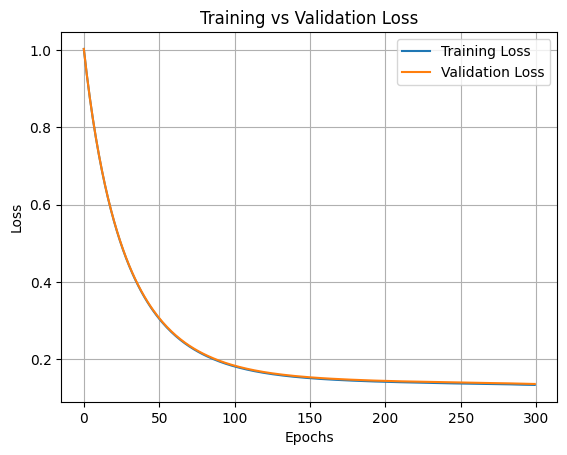

In [19]:
results = model.evals_result()

train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

PermutationExplainer explainer: 1001it [02:33,  6.35it/s]                                                              


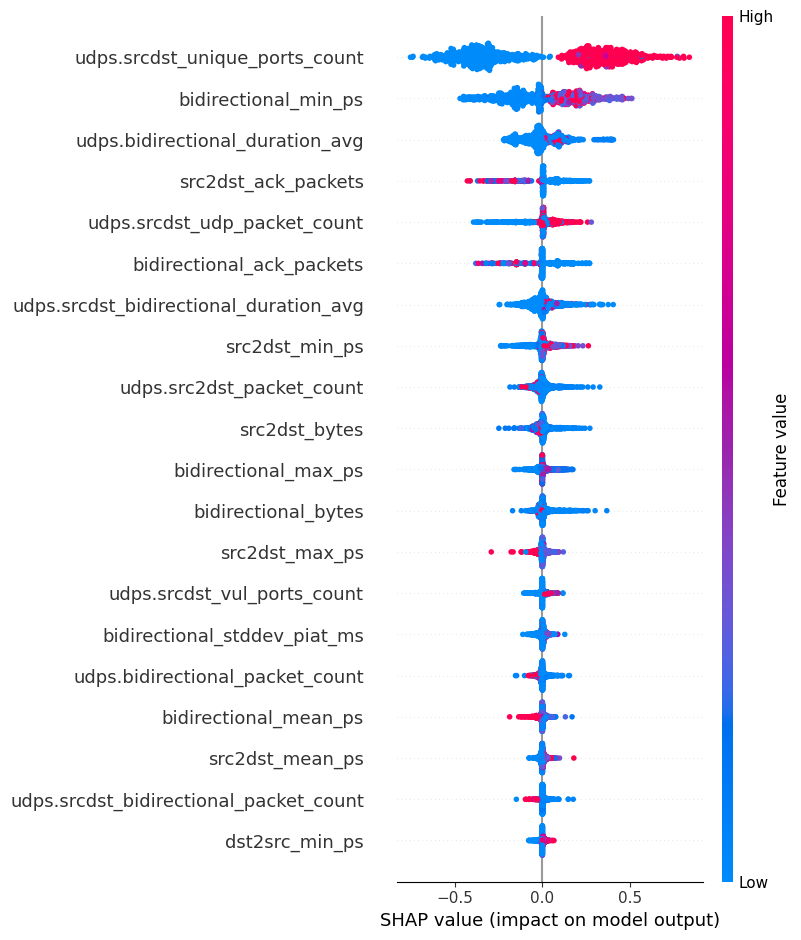

In [20]:
X_sample = X_test.sample(1000, random_state=42)
explainer = shap.Explainer(model.predict, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=np.random.default_rng(42))

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.931075
Weighted F1: 0.9309992764610663
Macro F1: 0.9080240334065622
ROC-AUC: 0.9916629795833334


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     20000
    DoS_ATTACK       0.89      0.83      0.86     10000
NON_DoS_ATTACK       0.84      0.89      0.87     10000

      accuracy                           0.93     40000
     macro avg       0.91      0.91      0.91     40000
  weighted avg       0.93      0.93      0.93     40000

